<a href="https://colab.research.google.com/github/BigFoots625/IntroductionMachineLearningwithPython/blob/main/Chapter3_UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Learning and Preprocessing**
Unsupervised learning encompasses tasks where we only have the input data ($X$) and no corresponding output labels ($y$). The algorithm's job is to discover the underlying structure or hidden patterns within the data.

The book divides these tasks into two main categories:
1. **Dataset Transformations:** Algorithms that create a new representation of the data. This is often used for dimensionality reduction (compressing the data while keeping essential information) or scaling (preparing data for supervised learning models).
2. **Clustering:** Algorithms that partition data into distinct groups of similar items.

In [1]:
!pip install mglearn
import mglearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_digits, make_blobs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 6.6 MB/s eta 0:00:00


### **Theoretical Explanation: Preprocessing and Scaling**
Many supervised machine learning models (especially Neural Networks and SVMs) compute distances between data points. If the features are on vastly different scales, the model will inherently bias its learning toward the feature with the largest magnitude, ignoring the others.

Unsupervised transformations solve this by scaling the data. `scikit-learn` provides several methods:
1. **StandardScaler:** Centers the data around 0 and scales it to have a variance of 1. It does not guarantee any specific minimum or maximum value.
   $$x_{scaled} = \frac{x - \mu}{\sigma}$$
2. **MinMaxScaler:** Shifts the data such that all features are exactly between 0 and 1.
   $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
3. **RobustScaler:** Uses the median and quartiles instead of the mean and variance. This makes it ignore extreme outliers that would otherwise skew the scaling.
4. **Normalizer:** Scales each *data point* (row) independently so that its feature vector has a Euclidean length of 1. It projects data onto a sphere, useful when only the direction (angle) of the data matters, such as in text classification.

**The Golden Rule of Scaling:** You must *always* fit the scaler on the training data only (`scaler.fit(X_train)`), and then use that exact same scaler to transform both the training and test sets. If you scale the test set independently using its own min/max values, you shift the data in a way that destroys the relationship between the training and test sets.

In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
from sklearn.svm import SVC

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=1)

# Initialize the scaler and fit it on the training data ONLY
scaler = MinMaxScaler()
scaler.fit(X_train)

# Transform both training and test data using the SAME scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train an SVM on the scaled data to see the improvement
svm = SVC(C=100)
svm.fit(X_train_scaled, y_train)
print(f"SVM Test accuracy on scaled data: {svm.score(X_test_scaled, y_test):.3f}")

SVM Test accuracy on scaled data: 0.972


### **Theoretical Explanation: Dimensionality Reduction via PCA**
Principal Component Analysis (PCA) is a foundational method for dimensionality reduction and feature extraction.

Mathematically, PCA rotates the dataset so that the rotated features are statistically uncorrelated. It identifies the direction in the feature space that contains the most variance (the first principal component). It then finds the next direction that contains the most variance, under the strict condition that it must be orthogonal (at a right angle) to the first component.

Once these components are found, we can reduce dimensionality by dropping the components that carry the least variance (essentially discarding the "noise" while keeping the "signal").

In [3]:
from sklearn.decomposition import PCA

# PCA works best on data with zero mean and unit variance
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

# Keep the first two principal components
pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print("Original dataset shape:", X_scaled.shape)
print("PCA reduced dataset shape:", X_pca.shape)

Original dataset shape: (569, 30)
PCA reduced dataset shape: (569, 2)


### **Theoretical Explanation: Non-Negative Matrix Factorization (NMF)**
NMF is another feature extraction algorithm. While PCA tries to explain the variance using orthogonal components (which can involve adding and subtracting negative numbers), NMF places a strict constraint: the components and coefficients must be strictly non-negative.

Because it can only *add* components together, NMF models are often much easier to interpret. It breaks data down into constituent parts. For example, when applied to audio, it might isolate different instruments. When applied to text or images, it pulls out distinct topics or facial features. NMF requires non-negative data to begin with (so we often use `MinMaxScaler` before applying it).

In [4]:
from sklearn.decomposition import NMF

# NMF requires non-negative data
scaler = MinMaxScaler()
scaler.fit(cancer.data)
X_scaled_minmax = scaler.transform(cancer.data)

# Extract 15 non-negative components
nmf = NMF(n_components=15, random_state=0, max_iter=1000)
nmf.fit(X_scaled_minmax)
X_nmf = nmf.transform(X_scaled_minmax)

print("Original shape:", X_scaled_minmax.shape)
print("NMF reduced shape:", X_nmf.shape)

Original shape: (569, 30)
NMF reduced shape: (569, 15)


### **Theoretical Explanation: Manifold Learning (t-SNE)**
PCA and NMF are linear transformations. For highly complex, non-linear data distributions, they often fail to separate classes effectively in lower dimensions. This is where Manifold Learning algorithms like **t-SNE** (t-Distributed Stochastic Neighbor Embedding) come in.

t-SNE focuses on preserving the local structure of the data. It computes the probability that pairs of data points are related in the high-dimensional space. It then attempts to map these points into a 2D or 3D space such that those relationship probabilities are perfectly preserved.

*Crucial Note:* t-SNE is strictly an exploratory visualization tool. It does not learn a function that can transform new, unseen data, which is why it has a `fit_transform` method but no `transform` method.

In [5]:
from sklearn.manifold import TSNE

digits = load_digits()

# Apply t-SNE for 2D visualization
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)

print("Original Digits shape:", digits.data.shape)
print("t-SNE reduced shape:", digits_tsne.shape)

Original Digits shape: (1797, 64)
t-SNE reduced shape: (1797, 2)


### **Theoretical Explanation: k-Means Clustering**
Clustering algorithms partition the dataset into distinct groups. **k-Means** tries to find cluster centers (centroids) that represent specific regions of the data.

The algorithm follows an iterative process:
1. Randomly initialize $k$ cluster centers.
2. **Assignment Step:** Assign each data point to the closest cluster center (usually measured by Euclidean distance).
3. **Update Step:** Recalculate each cluster center by taking the mean of all the data points assigned to it.
4. Repeat steps 2 and 3 until the cluster assignments no longer change.

While fast and easy to understand, k-Means struggles with complex cluster shapes (like elongated moons or concentric circles) because it relies on drawing linear boundaries between centroids.

In [6]:
from sklearn.cluster import KMeans

# Generate synthetic data
X_blobs, y_blobs = make_blobs(random_state=1)

# Build the clustering model
kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
kmeans.fit(X_blobs)

print("k-Means Cluster memberships:\n", kmeans.labels_)

k-Means Cluster memberships:
 [0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]


### **Theoretical Explanation: Agglomerative Clustering**
Agglomerative clustering uses a "bottom-up" hierarchical approach.
1. It starts by declaring each individual data point as its own cluster.
2. It finds the two clusters that are most similar and merges them.
3. It repeats this process until all points are merged into a single massive cluster, or until a stopping criterion (like `n_clusters=3`) is met.

Because it builds a hierarchy of merges, we can visualize the entire process using a tree diagram called a **dendrogram**. The y-axis of the dendrogram indicates the distance between two clusters at the exact moment they were merged.

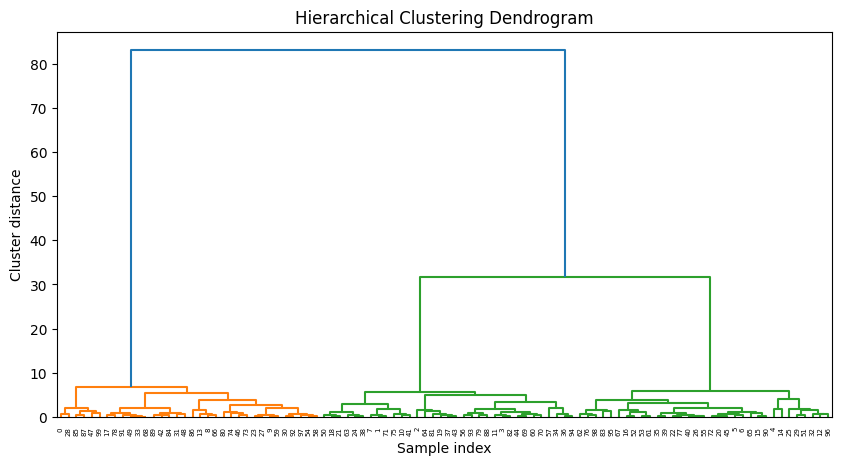

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, ward

# Scikit-learn can perform the clustering
agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X_blobs)

# SciPy is required to compute the linkage array and plot the dendrogram
linkage_array = ward(X_blobs)

plt.figure(figsize=(10, 5))
dendrogram(linkage_array)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

### **Theoretical Explanation: DBSCAN**
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) solves two major problems with k-Means and Agglomerative clustering: it doesn't require you to guess the number of clusters in advance, and it can capture highly complex, non-linear cluster shapes.

It works by identifying dense regions of data. It uses two parameters: `min_samples` and `eps` (epsilon, a distance radius).
1. If a data point has at least `min_samples` other points within a distance of `eps`, it is classified as a **core point**.
2. All core points that are within `eps` distance of each other are merged into a single cluster.
3. Points that are not core points but fall within the radius of a core point are added to that cluster (boundary points).
4. Any point that is neither a core point nor close to a core point is classified as **noise** and labeled with `-1`.

In [8]:
from sklearn.cluster import DBSCAN

# eps is the radius, min_samples is the core point threshold
dbscan = DBSCAN(eps=1.5, min_samples=3)
clusters = dbscan.fit_predict(X_blobs)

print("DBSCAN Cluster memberships (note that -1 indicates noise):\n", clusters)

DBSCAN Cluster memberships (note that -1 indicates noise):
 [ 0  1  1  1  2  2  2  1  0  0  1  1  2  0 -1  2  2  0  1  1  2  1  2  0
  1  2  2  0  0  2  0  0  2  0  1  2  1  1  1  2  2  1  0  1  1  2  0  0
  0  0  1  2  2  2  0  2  1  1  0  0  1  2  2  1  1  2  0  2  0  1  1  1
  2  0  0  1  2  2  0  1  0  1  1  2  0  0  0  0  1  0  2  0  0  1  1  2
  2  0  2  0]


### **Theoretical Explanation: Evaluating Clustering with ARI**
Evaluating unsupervised learning is difficult because we usually lack the ground truth labels. If we *do* have true labels (for benchmarking purposes), standard accuracy metrics fail because cluster numbering is completely arbitrary (e.g., k-Means might label a cluster `0`, while the true label is `2`).

To evaluate performance accurately, we use the **Adjusted Rand Index (ARI)** or **Normalized Mutual Information (NMI)**. These metrics measure the similarity between the true assignments and the cluster assignments, accounting for chance. An ARI of 1.0 indicates perfect alignment, while an ARI of 0.0 indicates random assignment.

In [9]:
from sklearn.metrics.cluster import adjusted_rand_score

# Compare k-Means against the ground truth labels
ari_kmeans = adjusted_rand_score(y_blobs, kmeans.labels_)
print(f"Adjusted Rand Index for k-Means: {ari_kmeans:.3f}")

# Compare DBSCAN against the ground truth labels
ari_dbscan = adjusted_rand_score(y_blobs, clusters)
print(f"Adjusted Rand Index for DBSCAN: {ari_dbscan:.3f}")

Adjusted Rand Index for k-Means: 1.000
Adjusted Rand Index for DBSCAN: 0.985


### **Chapter 3 Summary**
* **Objective:** We explored dataset transformations for scaling and feature extraction, alongside algorithms for grouping unstructured data.
* **Key Concepts Covered:**
    * **Scaling:** StandardScaler, MinMaxScaler, RobustScaler, Normalizer. Strict adherence to fitting only on training data.
    * **Dimensionality Reduction:** PCA (variance maximization), NMF (additive, non-negative components), and t-SNE (non-linear mapping for visualization).
    * **Clustering:** k-Means (centroid-based), Agglomerative (hierarchical tree-based), and DBSCAN (density-based with noise detection).
    * **Evaluation:** Using Adjusted Rand Index (ARI) to evaluate arbitrary cluster labels against ground truth.